In [1]:
%matplotlib inline

import os
import sys
import yaml
import copy

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../../')
sys.path.append('../../../../')

%load_ext autoreload
%autoreload 2
    
from computer_vision.yolov11_pose.utils import DEFAULT_CFG_DICT
from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.misc import alpha_bending, instance2mask
from computer_vision.yolov11_pose.cfg import get_cfg
from computer_vision.yolov11_pose.data.build import build_yolo_dataset, seed_worker, build_dataloader
from computer_vision.yolov11_pose.utils.ops import xywh2xyxy
from computer_vision.yolov11_pose.utils.viz import general_skeleton_overlay

In [2]:
from matplotlib import patches
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

In [3]:
args=parser.parse_args('--deterministic'.split())

task='pose'
if task=='pose':
    data_dirpath='D:/data/ultralytics/coco8-pose'
    data_config='../coco8-pose.yaml'
elif task=='detect':
    data_dirpath='D:/data/ultralytics/coco/images/train2017'
    data_config='../coco.yaml'
elif task=='segment':
    data_dirpath='D:/data/ultralytics/coco8-seg'
    data_config='../coco8-seg.yaml'

hyp=get_cfg()
dataset=build_yolo_dataset(args=args, cfg=hyp, task=task, img_path=data_dirpath, batch=args.batch_size or hyp.batch, 
                   data=data_config,  mode='validation', rect=False, stride=32, channels=3)
for i in range(4): print(dataset.labels[i]['cls'].shape)

dataloader=build_dataloader(dataset, batch=hyp.batch, workers=1, shuffle=True, drop_last=True, pin_memory=True)

In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco8-pose\labels\train.cache
Scanning D:\data\ultralytics\coco8-pose\labels\train.cache... 8 images, 0 backgrounds, 0 corrupts
(1, 1)
(2, 1)
(3, 1)
(1, 1)


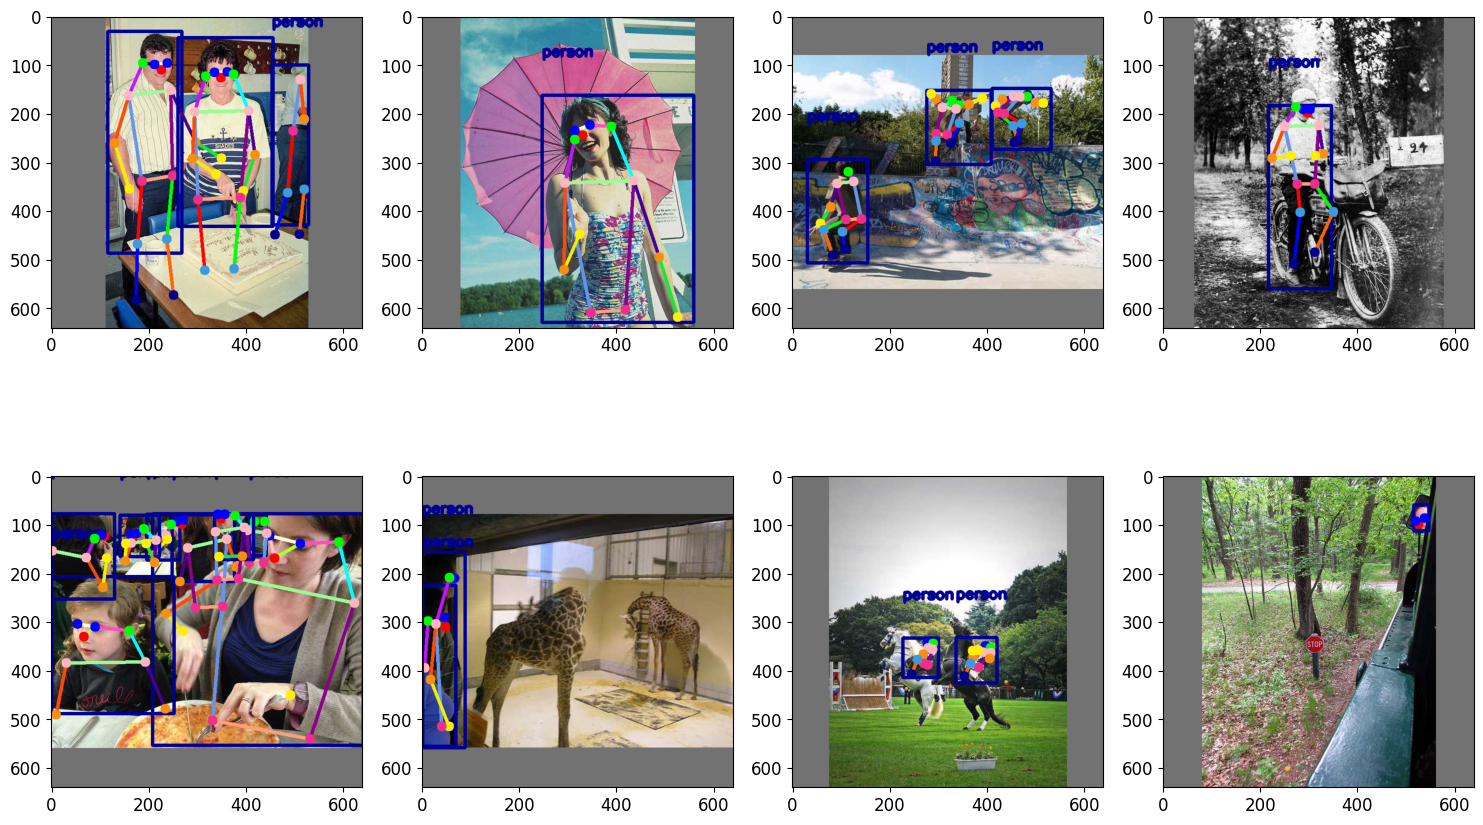

In [4]:
data=next(iter(dataloader))

ncols=4
nrows=int(np.ceil(len(data['img'])/ncols))

_, ax=plt.subplots(nrows,ncols,figsize=(15,10))
for i, img in enumerate(data['img']): # img: CxHxW

    r, c=i//ncols, i%ncols
    valid=data['batch_idx']==i
    bboxes=data['bboxes'][valid]
    cls=data['cls'][valid]
    keypoints=data['keypoints'][valid] if 'keypoints' in data else None
    masks=data['masks'][i] if 'masks' in data else None # HxW

    classes=[dataset.data['names'][int(c)] for c in cls.flatten()] # *N,1) -> (N,)
    height, width=img.shape[1:]

    # RGB image tensor to BGR array
    img=img.permute(1,2,0).contiguous().numpy() # HxWxC
    img=img[:,:,::-1] # RGB to BGR
    
    # Bounding boxes
    #--- xywh to xyxy
    bboxes=bboxes.clone() # Nx4
    bboxes=xywh2xyxy(bboxes)
    # denormalize bboxes
    bboxes[...,[0,2]]*=width 
    bboxes[...,[1,3]]*=height
    bboxes=bboxes.numpy()

    # processing keypoints
    if keypoints is not None:
        keypoints[...,0]*=width
        keypoints[...,1]*=height
        keypoints=keypoints.numpy()

    # processing masks
    if masks is not None:
        masks=masks.clone() 
        if masks.shape[0]>1: masks=torch.argsort(masks, dim=0)
        if masks.ndim==3:
            masks=masks.permute(1,2,0).contiguous()
        masks=masks.numpy() # HxWxC
        if masks.shape[:2] != img.shape[:2]:
            masks=cv2.resize(masks, (width, height), interpolation=cv2.INTER_NEAREST) # if mask is of shape HxWx1, cv2.resize give shape HxW
        if masks.ndim!=img.ndim:
            masks=np.repeat(masks[...,None], 3, axis=-1)

    # display image (overlaid)
    if masks is not None:  ax[r,c].imshow(alpha_bending(masks, img[...,::-1], 0.4))
    elif keypoints is not None:
        img=general_skeleton_overlay(img_bgr=img, class_names=classes, bboxes=bboxes, keypoints=keypoints)
        ax[r,c].imshow(img[...,::-1])
    else: ax[r,c].imshow(img[...,::-1])
        
    if keypoints is None:
        for j, (box,cls) in enumerate(zip(bboxes, classes)):
            # Create a Rectangle patch
            rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
            # Add the patch to the Axes
            ax[r,c].add_patch(rect)
            ax[r,c].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)

plt.tight_layout()